# Enterprise Retail Intelligence Platform

## Notebook 04 : Exploratory Data Analysis (EDA)

### Author
**Shobha Saxena**

---

## Project Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the processed retail datasets to identify trends, patterns, customer behavior, product performance, regional sales distribution, transportation efficiency, and other business insights.

The insights generated in this notebook will support:

- Business Decision Making
- Customer Segmentation
- Product Performance Analysis
- Sales Trend Analysis
- Regional Performance Evaluation
- Power BI Dashboard Development

---

## Datasets Used

- Customers
- Products
- Orders
- Suppliers
- Inventory
- Transportation
- Payments
- Returns
- Customer Discounts

---

## Output

Business insights and visualizations that will be used in the final dashboard and project documentation.

# Import Required Libraries

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization Settings
plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="Set2"
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Project Configuration

In [2]:
# ============================================================
# Project Configuration
# ============================================================

DATA_PATH = Path("../data/processed")

print("Processed Data Path:")
print(DATA_PATH.resolve())

Processed Data Path:
D:\My Project\enterprise-retail-intelligence-platform-main\python\data\processed


# Load Processed Datasets

In [3]:
# ============================================================
# Load Processed Datasets
# ============================================================

customers_df = pd.read_csv(DATA_PATH / "customers.csv")
products_df = pd.read_csv(DATA_PATH / "products.csv")
orders_df = pd.read_csv(DATA_PATH / "orders.csv")
suppliers_df = pd.read_csv(DATA_PATH / "suppliers.csv")
inventory_df = pd.read_csv(DATA_PATH / "inventory.csv")
transportation_df = pd.read_csv(DATA_PATH / "transportation.csv")
payments_df = pd.read_csv(DATA_PATH / "payments.csv")
returns_df = pd.read_csv(DATA_PATH / "returns.csv")
customer_discounts_df = pd.read_csv(DATA_PATH / "customer_discounts.csv")

print("All processed datasets loaded successfully!")

All processed datasets loaded successfully!


In [4]:
# ============================================================
# Dataset Dictionary
# ============================================================

datasets = {
    "Customers": customers_df,
    "Products": products_df,
    "Orders": orders_df,
    "Suppliers": suppliers_df,
    "Inventory": inventory_df,
    "Transportation": transportation_df,
    "Payments": payments_df,
    "Returns": returns_df,
    "Customer Discounts": customer_discounts_df
}

print(f"Total datasets loaded : {len(datasets)}")

Total datasets loaded : 9


# Dataset Overview

In [5]:
# ============================================================
# Dataset Summary
# ============================================================

summary = []

for name, df in datasets.items():

    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

summary_df = pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns
0,Customers,793,4
1,Products,1861,5
2,Orders,9800,14
3,Suppliers,17,9
4,Inventory,1861,10
5,Transportation,9800,10
6,Payments,9800,8
7,Returns,490,8
8,Customer Discounts,793,8


In [6]:
# ============================================================
# Preview Orders Dataset
# ============================================================

orders_df.head(
)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,product_id,country,city,state,postal_code,region,sales,created_at
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,FUR-BO-10001798,United States,Henderson,Kentucky,42420.0,South,261.96,2026-08-04 15:34:05.274309
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,FUR-CH-10000454,United States,Henderson,Kentucky,42420.0,South,731.94,2026-08-04 15:34:05.274309
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,OFF-LA-10000240,United States,Los Angeles,California,90036.0,West,14.62,2026-08-04 15:34:05.274309
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,FUR-TA-10000577,United States,Fort Lauderdale,Florida,33311.0,South,957.58,2026-08-04 15:34:05.274309
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,OFF-ST-10000760,United States,Fort Lauderdale,Florida,33311.0,South,22.37,2026-08-04 15:34:05.274309


# Descriptive Statistics

This section provides a statistical overview of all numerical variables present in the datasets.

The purpose is to understand:

- Distribution of numerical variables
- Central tendency
- Variability
- Minimum and Maximum values
- Potential anomalies

In [8]:
# ============================================================
# Orders Dataset Statistics
# ============================================================

orders_df.describe().T

,count,mean,std,min,25%,50%,75%,max
row_id,9800.0,4900.500000,2829.160653,1.00,2450.75,4900.50,7350.250,9800.00
postal_code,9789.0,55273.322403,32041.223413,1040.00,23223.00,58103.00,90008.000,99301.00
sales,9800.0,230.769079,626.651906,0.44,17.25,54.49,210.605,22638.48


In [9]:
# ============================================================
# Transportation Statistics
# ============================================================

transportation_df.describe().T

,count,mean,std,min,25%,50%,75%,max
transport_id,9800.0,4900.500000,2829.160653,1.0,2450.75,4900.500,7350.25,9800.00
order_row_id,9800.0,4900.500000,2829.160653,1.0,2450.75,4900.500,7350.25,9800.00
delivery_cost,9800.0,29.937861,11.602605,10.0,19.66,29.935,40.21,49.99


In [10]:
# ============================================================
# Inventory Statistics
# ============================================================

inventory_df.describe().T

,count,mean,std,min,25%,50%,75%,max
inventory_id,1861.0,931.000000,537.368744,1.0,466.0,931.0,1396.0,1861.0
supplier_id,1861.0,8.980656,4.900916,1.0,5.0,9.0,13.0,17.0
stock_quantity,1861.0,275.449758,128.879344,50.0,168.0,277.0,386.0,500.0
reorder_level,1861.0,49.985492,17.888583,20.0,35.0,50.0,66.0,80.0


## Initial Business Observation

### Orders

The Orders dataset contains sales information for all customer transactions.

The descriptive statistics help identify:

- Sales range
- Average sales
- High-value orders
- Distribution spread

---

### Transportation

Transportation statistics help evaluate:

- Delivery cost distribution
- Transportation performance
- Logistics variation

---

### Inventory

Inventory statistics provide an overview of:

- Available stock
- Reorder level
- Inventory capacity

# Univariate Analysis

Univariate analysis focuses on understanding the distribution of individual variables.

This section includes:

- Sales Distribution
- Ship Mode Distribution
- Regional Distribution
- Customer Distribution
- Product Distribution

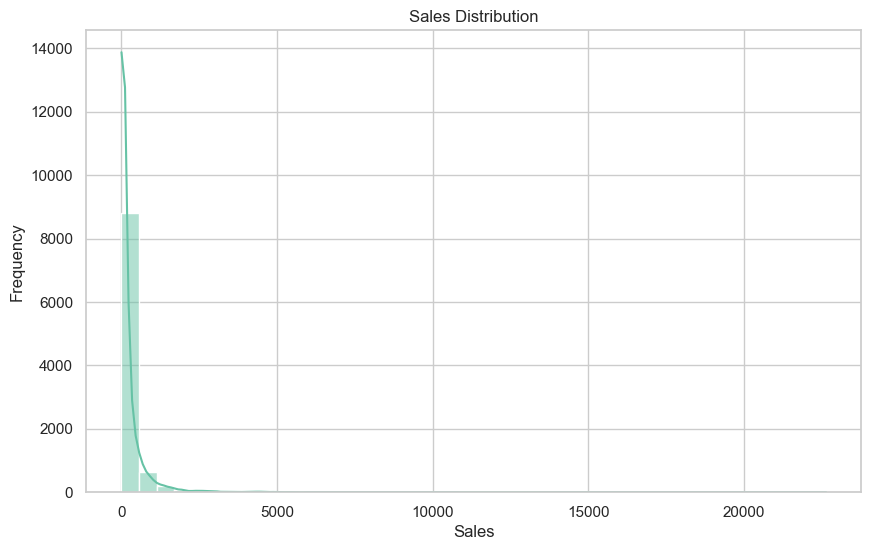

In [11]:
# ============================================================
# Sales Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=orders_df,
    x="sales",
    bins=40,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## Business Insight: Sales Distribution

### Observation

- The sales distribution is highly right-skewed.
- Most customer orders are low-value transactions.
- A small number of orders contribute very high sales values.

### Business Interpretation

This indicates that the business receives a large volume of regular purchases while a limited number of premium orders generate a significant share of total revenue.

### Recommendation

- Identify high-value customers for premium loyalty programs.
- Increase average order value through product bundles and upselling strategies.

# Ship Mode Analysis

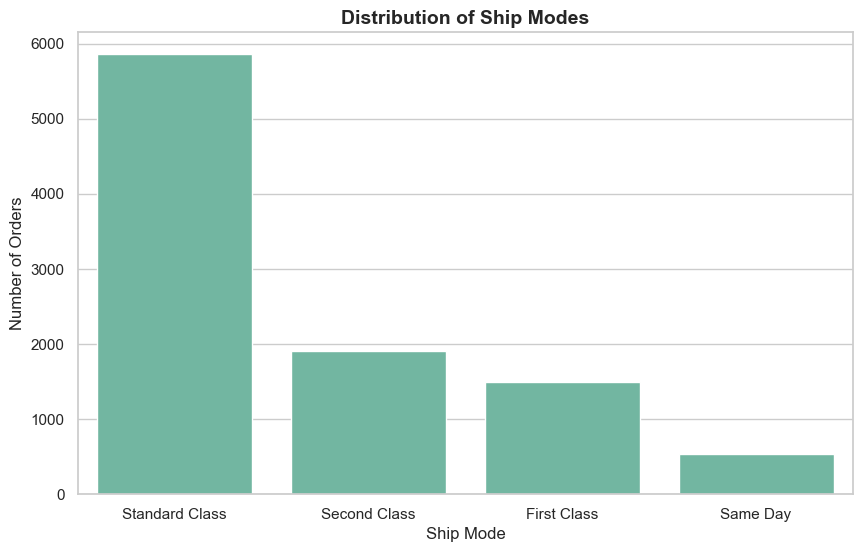

In [12]:
# ============================================================
# Ship Mode Distribution
# ============================================================

plt.figure(figsize=(10,6))

ship_mode_counts = (
    orders_df["ship_mode"]
    .value_counts()
    .sort_values(ascending=False)
)

sns.barplot(
    x=ship_mode_counts.index,
    y=ship_mode_counts.values
)

plt.title("Distribution of Ship Modes", fontsize=14, fontweight="bold")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.show()

# Regional Sales Analysis

In [13]:
# ============================================================
# Regional Sales Analysis
# ============================================================

region_sales = (
    orders_df
    .groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

region_sales

,region,sales
0,West,710219.77
1,East,669518.85
2,Central,492646.90
3,South,389151.45


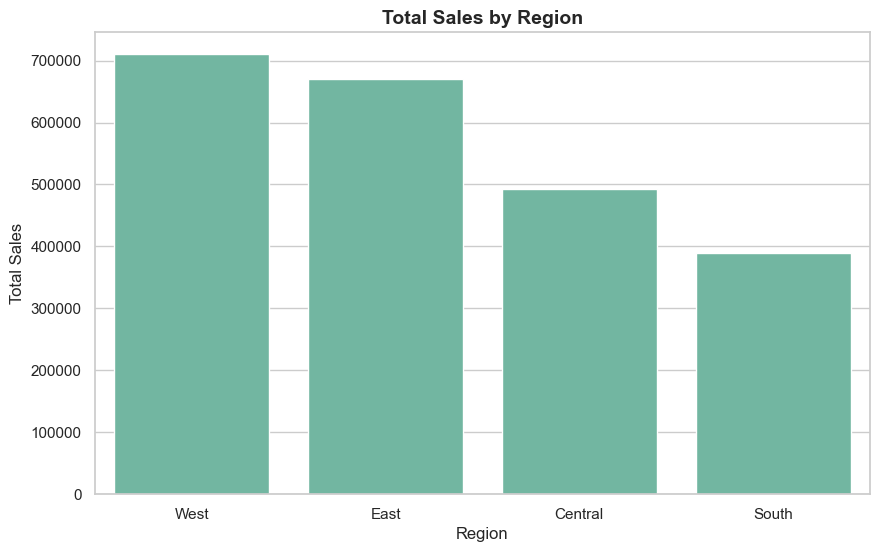

In [14]:
# ============================================================
# Regional Sales Visualization
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=region_sales,
    x="region",
    y="sales"
)

plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

## Business Insight: Regional Sales

### Observation

The visualization compares total sales across different regions.

### Business Interpretation

Regions with higher sales contribute significantly to overall business revenue, while lower-performing regions may require additional marketing efforts or operational improvements.

### Recommendation

- Focus inventory planning on high-performing regions.
- Develop sales campaigns for underperforming regions.
- Monitor regional demand trends for better forecasting.

# Sales Trend Analysis

In [15]:
# ============================================================
# Monthly Sales Trend
# ============================================================

orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

monthly_sales = (
    orders_df
    .groupby(orders_df["order_date"].dt.to_period("M"))["sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales = monthly_sales.reset_index()
monthly_sales.columns = ["Month", "Sales"]

monthly_sales.head()

,Month,Sales
0,2015-01,14205.71
1,2015-02,4519.92
2,2015-03,55205.83
3,2015-04,27906.86
4,2015-05,23644.30


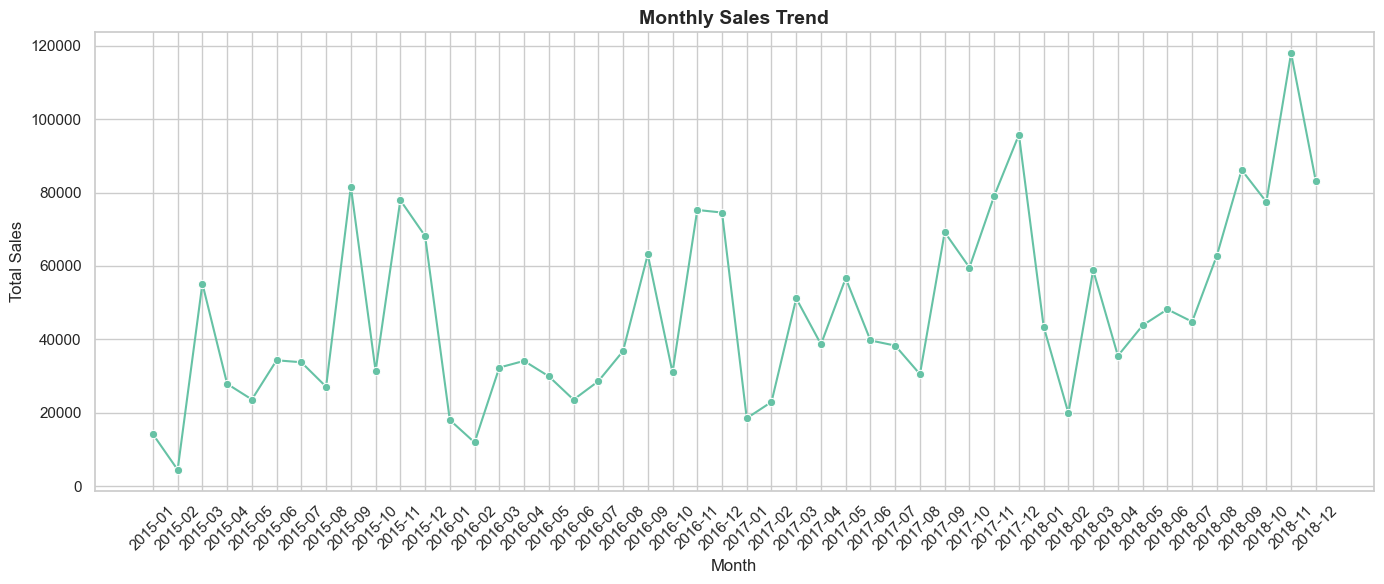

In [16]:
# ============================================================
# Monthly Sales Trend Visualization
# ============================================================

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Business Insight: Monthly Sales Trend

### Observation

The monthly sales trend highlights fluctuations in customer purchasing behavior over time.

### Business Interpretation

Peak sales periods may indicate seasonal demand, promotional campaigns, or holiday shopping patterns.

### Recommendation

- Increase inventory before high-demand periods.
- Plan promotional campaigns during low-sales months.
- Use historical trends for demand forecasting.

# Customer Analysis

In [17]:
# ============================================================
# Top Customers by Sales
# ============================================================

customer_sales = (
    orders_df
    .groupby("customer_id")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_customers = customer_sales.head(10)

top_customers

,customer_id,sales
0,SM-20320,25043.07
1,TC-20980,19052.22
2,RB-19360,15117.35
3,TA-21385,14595.62
4,AB-10105,14473.57
5,KL-16645,14175.23
6,SC-20095,14142.34
7,HL-15040,12873.30
8,SE-20110,12209.44
9,CC-12370,12129.08


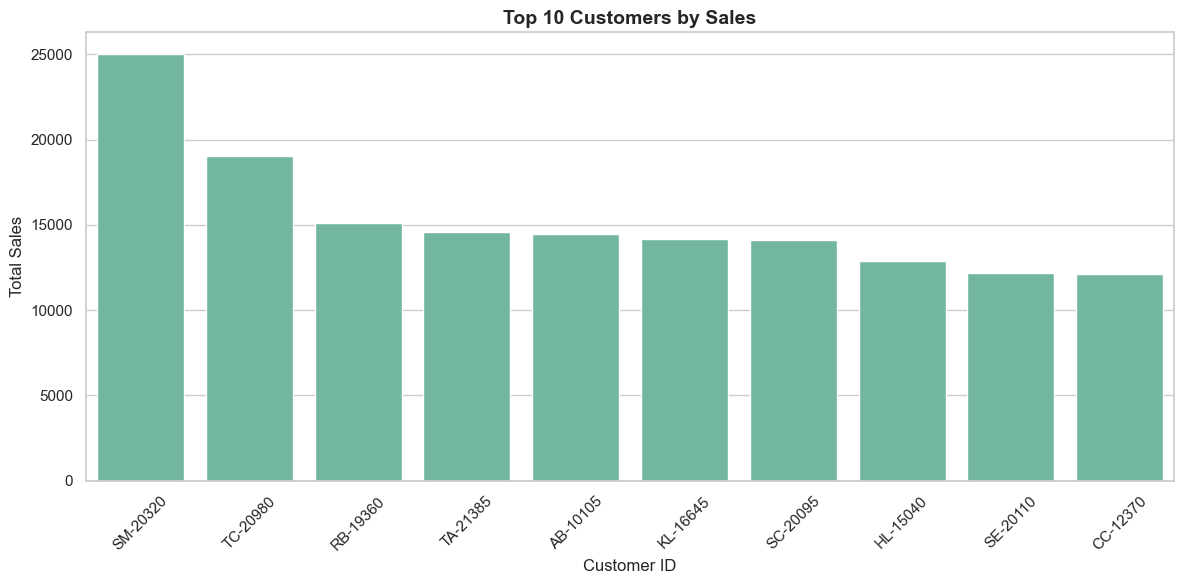

In [18]:
# ============================================================
# Top 10 Customers Visualization
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers,
    x="customer_id",
    y="sales"
)

plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Business Insight: Top Customers

### Observation

A small group of customers contributes a significant percentage of total sales.

### Business Interpretation

These customers are highly valuable and should be retained through personalized engagement and loyalty programs.

### Recommendation

- Reward top customers with exclusive discounts.
- Launch VIP customer programs.
- Monitor purchasing behavior to prevent customer churn.

# Product Performance Analysis

In [19]:
# ============================================================
# Top Products by Sales
# ============================================================

product_sales = (
    orders_df
    .merge(
        products_df,
        on="product_id",
        how="left"
    )
    .groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products = product_sales.head(10)

top_products

,product_name,sales
0,Canon imageCLASS 2200 Advanced Copier,61599.83
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.57
4,GBC DocuBind TL300 Electric Binding System,19823.48
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50
6,Hewlett Packard LaserJet 3310 Copier,18839.68
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90
8,GBC DocuBind P400 Electric Binding System,17965.07
9,High Speed Automatic Electric Letter Opener,17030.31


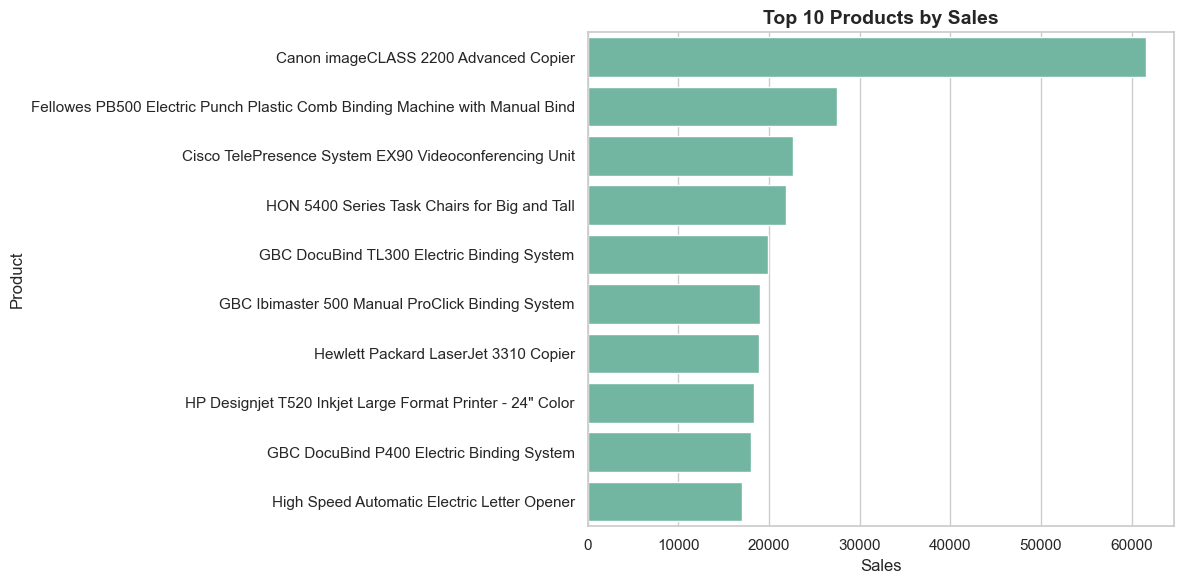

In [20]:
# ============================================================
# Product Performance Visualization
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_products,
    x="sales",
    y="product_name"
)

plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

## Business Insight: Product Performance

### Observation

A limited number of products generate the highest revenue.

### Business Interpretation

These products represent the strongest revenue drivers and should receive priority in inventory planning and promotional campaigns.

### Recommendation

- Maintain sufficient stock for high-performing products.
- Bundle high-performing products with slower-moving items.
- Analyze customer demand patterns for inventory optimization.

# Inventory Analysis

In [21]:
# ============================================================
# Inventory Status
# ============================================================

inventory_df.head()

,inventory_id,product_id,supplier_id,warehouse_name,warehouse_location,stock_quantity,reorder_level,stock_status,last_restock_date,last_updated
0,1,FUR-BO-10000112,1,Furniture Warehouse,New York,60,62,Low Stock,2026-07-19,2026-08-06 01:40:20.449387
1,2,FUR-BO-10000330,2,Furniture Warehouse,New York,249,25,In Stock,2026-07-28,2026-08-06 01:40:20.449387
2,3,FUR-BO-10000362,3,Furniture Warehouse,New York,207,55,In Stock,2026-06-23,2026-08-06 01:40:20.449387
3,4,FUR-BO-10000468,4,Furniture Warehouse,New York,449,36,In Stock,2026-06-25,2026-08-06 01:40:20.449387
4,5,FUR-BO-10000711,5,Furniture Warehouse,New York,496,78,In Stock,2026-06-21,2026-08-06 01:40:20.449387


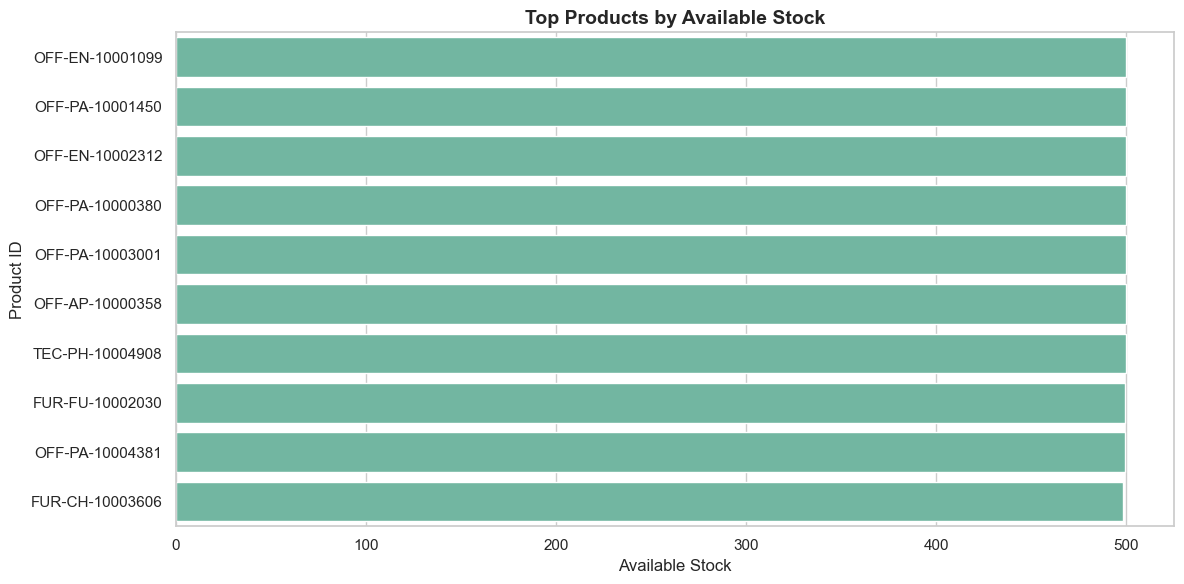

In [22]:
# ============================================================
# Top 10 Products by Available Stock
# ============================================================

top_inventory = (
    inventory_df
    .sort_values("stock_quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_inventory,
    x="stock_quantity",
    y="product_id"
)

plt.title("Top Products by Available Stock", fontsize=14, fontweight="bold")
plt.xlabel("Available Stock")
plt.ylabel("Product ID")

plt.tight_layout()

plt.show()

## Business Insight: Inventory

### Observation

Products with high stock levels indicate inventory availability, whereas low stock levels may increase the risk of stock-outs.

### Recommendation

- Monitor low-stock products regularly.
- Optimize reorder planning.
- Reduce excess inventory carrying costs.

# Payment Analysis

In [23]:
# ============================================================
# Payment Method Distribution
# ============================================================

payment_counts = (
    payments_df["payment_method"]
    .value_counts()
    .reset_index()
)

payment_counts.columns = ["Payment Method","Count"]

payment_counts

,Payment Method,Count
0,Debit Card,1664
1,Credit Card,1664
2,Wallet,1656
3,Cash,1635
4,Net Banking,1605
5,UPI,1576


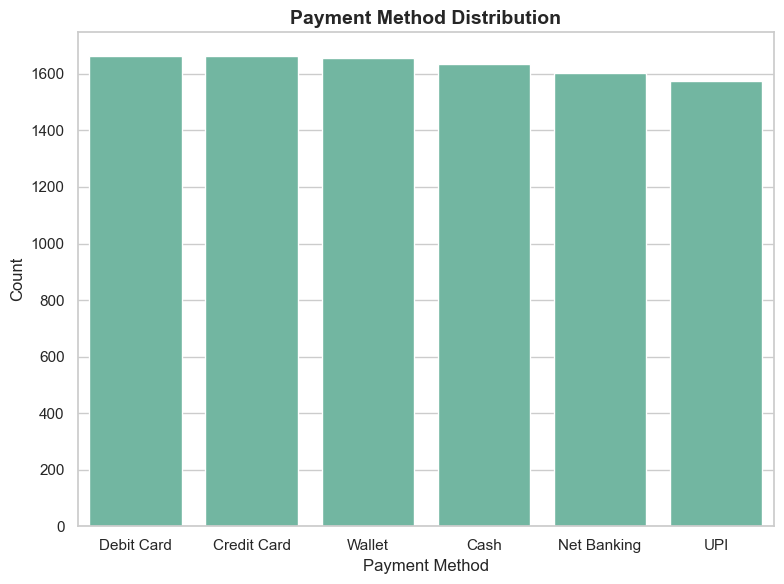

In [24]:
# ============================================================
# Payment Method Visualization
# ============================================================

plt.figure(figsize=(8,6))

sns.barplot(
    data=payment_counts,
    x="Payment Method",
    y="Count"
)

plt.title("Payment Method Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.show()

## Business Insight: Payment Methods

### Observation

Different customers prefer different payment methods.

### Recommendation

- Improve support for the most frequently used payment methods.
- Analyze transaction success rates by payment method.

# Return Analysis

In [25]:
# ============================================================
# Return Reason Distribution
# ============================================================

return_reason = (
    returns_df["return_reason"]
    .value_counts()
    .reset_index()
)

return_reason.columns = ["Reason","Count"]

return_reason

,Reason,Count
0,Late Delivery,105
1,Defective Product,92
2,Customer Changed Mind,85
3,Wrong Item,72
4,Damaged Product,70
5,Other,66


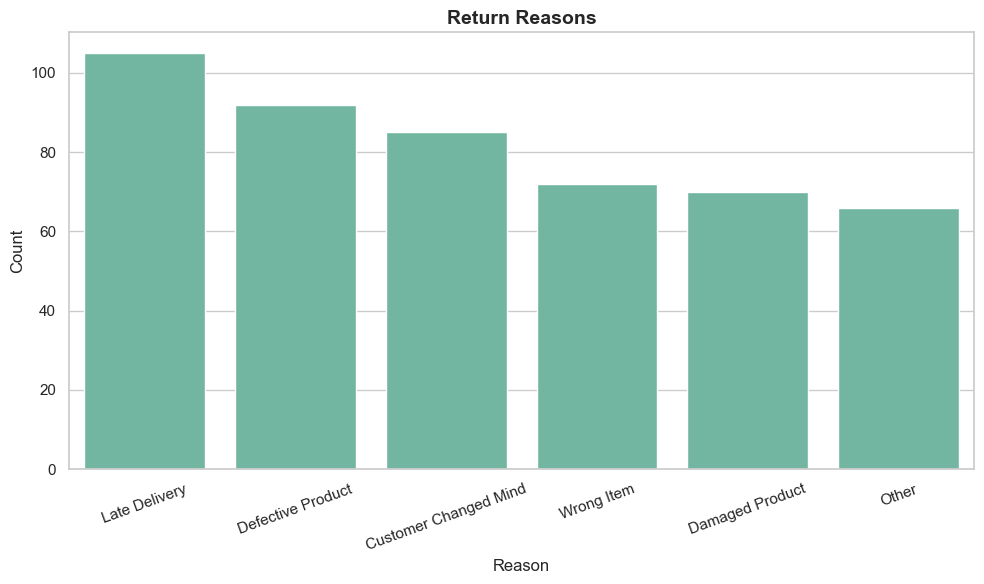

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=return_reason,
    x="Reason",
    y="Count"
)

plt.title("Return Reasons", fontsize=14, fontweight="bold")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Business Insight: Product Returns

### Observation

Product return reasons help identify operational issues and customer dissatisfaction.

### Recommendation

- Improve product quality.
- Strengthen packaging.
- Optimize logistics.
- Reduce return rate through customer feedback.

# Transportation Analysis

In [27]:
# ============================================================
# Shipment Status Distribution
# ============================================================

shipment_status = (
    transportation_df["shipment_status"]
    .value_counts()
    .reset_index()
)

shipment_status.columns = ["Shipment Status", "Count"]

shipment_status

,Shipment Status,Count
0,Delivered,8847
1,In Transit,903
2,Shipped,49
3,Pending,1


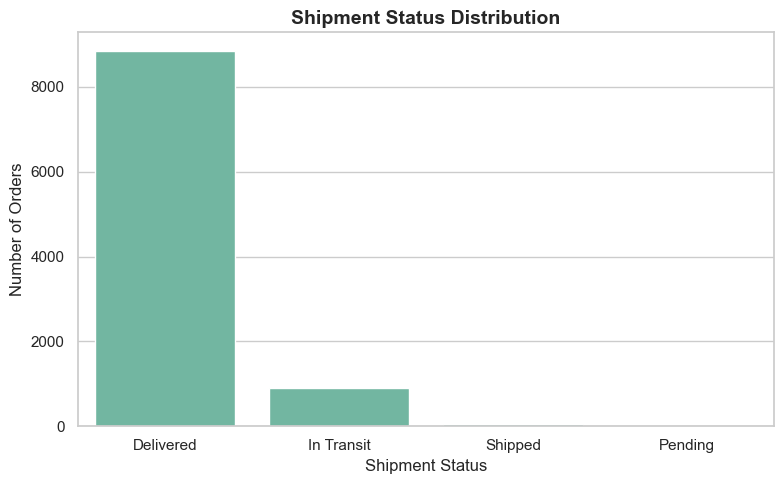

In [28]:
# ============================================================
# Shipment Status Visualization
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=shipment_status,
    x="Shipment Status",
    y="Count"
)

plt.title("Shipment Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## Business Insight: Transportation

### Observation

The transportation data shows the distribution of shipment statuses across all customer orders.

### Business Interpretation

Monitoring shipment status helps evaluate logistics performance and customer service quality.

### Recommendation

- Improve delayed shipment monitoring.
- Optimize delivery partners.
- Reduce delivery lead time.

# Final Business Findings

## Key Findings

### Sales

- Sales are highly right-skewed.
- A small percentage of orders generate most of the revenue.

---

### Customers

- A limited number of customers contribute significantly to total sales.
- Customer retention programs should focus on high-value customers.

---

### Products

- Top-performing products drive the majority of revenue.
- Inventory should prioritize these products.

---

### Regions

- Sales performance varies significantly across regions.
- Regional marketing strategies can improve weaker regions.

---

### Transportation

- Most shipments are successfully delivered.
- Logistics performance can be improved by reducing delayed deliveries.

---

### Returns

- Product returns provide valuable feedback for quality improvement.

# Business Recommendations

1. Develop loyalty programs for top customers.

2. Maintain adequate inventory for high-demand products.

3. Increase promotional activities in low-performing regions.

4. Improve logistics efficiency to reduce delivery delays.

5. Monitor return reasons to improve product quality.

6. Utilize historical sales trends for demand forecasting.

7. Integrate these insights into the Power BI dashboard for executive decision-making.

# Conclusion

The Exploratory Data Analysis identified key trends in customer purchasing behavior, product performance, regional sales, inventory, logistics, and returns.

The insights generated in this notebook provide a strong analytical foundation for:

- Feature Engineering
- Business KPI Development
- SQL Reporting
- Power BI Dashboard Creation

This notebook represents the exploratory analysis phase of the Enterprise Retail Intelligence Platform.